Dataset Shape: (50000, 21)
Epsilon: 4.0
Minimum Samples: 15

Number of Clusters: 6
Number of Noise Points: 2083

Cluster Counts:
-1    2083
 0    2857
 1      13
 2      12
 3      14
 4      12
 5       9
Name: count, dtype: int64

Silhouette Score: -0.0644


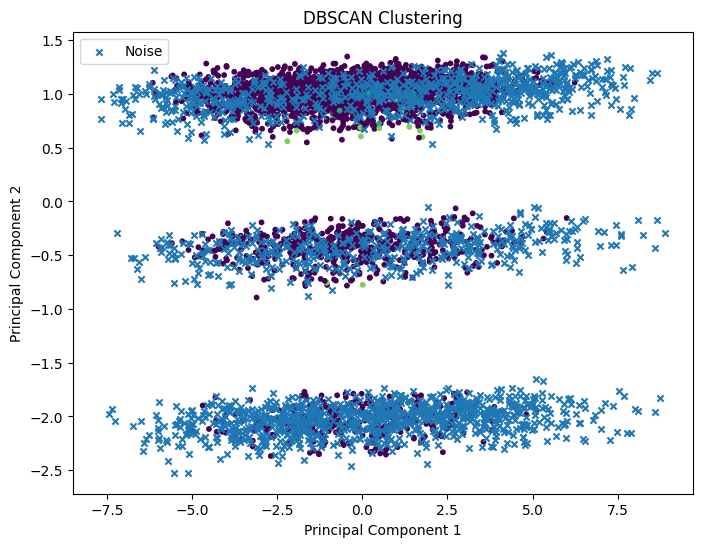

In [1]:
# ============================================================
# DBSCAN CLUSTERING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("/content/placement_predict_50k_adjusted (1).csv")

print("Dataset Shape:", df.shape)

# ------------------------------------------------------------
# 2. Select Features
# ------------------------------------------------------------

numeric_cols = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]

categorical_cols = [
    "Gender",
    "City",
    "CollegeTier",
    "Stream",
    "Specialisation",
    "Hostel",
    "HistoryOfBacklogs",
    "ExtraCurricular"
]

# ------------------------------------------------------------
# 3. Preprocessing
# ------------------------------------------------------------

imputer = SimpleImputer(strategy="median")

num_data = pd.DataFrame(
    imputer.fit_transform(df[numeric_cols]),
    columns=numeric_cols
)

cat_data = pd.get_dummies(
    df[categorical_cols],
    drop_first=True
)

features = pd.concat(
    [num_data, cat_data],
    axis=1
)

scaler = StandardScaler()

X = scaler.fit_transform(features)

# ------------------------------------------------------------
# 4. Sample Dataset
# ------------------------------------------------------------

sample_size = min(5000, len(X))

np.random.seed(42)

sample_indices = np.random.choice(
    len(X),
    sample_size,
    replace=False
)

X_sample = X[sample_indices]

# ------------------------------------------------------------
# 5. DBSCAN
# ------------------------------------------------------------

eps = 4.0
min_samples = 15

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples
)

labels = dbscan.fit_predict(X_sample)

# ------------------------------------------------------------
# 6. Cluster Information
# ------------------------------------------------------------

number_of_clusters = len(
    set(labels)
) - (1 if -1 in labels else 0)

number_of_noise = np.sum(
    labels == -1
)

print("Epsilon:", eps)
print("Minimum Samples:", min_samples)

print("\nNumber of Clusters:", number_of_clusters)
print("Number of Noise Points:", number_of_noise)

print("\nCluster Counts:")
print(pd.Series(labels).value_counts().sort_index())

# ------------------------------------------------------------
# 7. Silhouette Score
# ------------------------------------------------------------

non_noise = labels != -1

if number_of_clusters >= 2:

    score = silhouette_score(
        X_sample[non_noise],
        labels[non_noise]
    )

    print(
        "\nSilhouette Score:",
        round(score, 4)
    )

else:

    print(
        "\nSilhouette Score cannot be calculated."
    )

# ------------------------------------------------------------
# 8. PCA
# ------------------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)

# ------------------------------------------------------------
# 9. DBSCAN Visualization
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[non_noise,0],
    X_pca[non_noise,1],
    c=labels[non_noise],
    cmap="viridis",
    s=10
)

# Show noise points
if np.any(~non_noise):

    plt.scatter(
        X_pca[~non_noise,0],
        X_pca[~non_noise,1],
        marker="x",
        s=20,
        label="Noise"
    )

    plt.legend()

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("DBSCAN Clustering")

plt.show()